In [1]:
import math
from matplotlib import pyplot as plt
import control as ctrl

s0: -2.6666666666666665
Kp: 4.7407407407407405, Kv: 10.666666666666666, Ka: 3


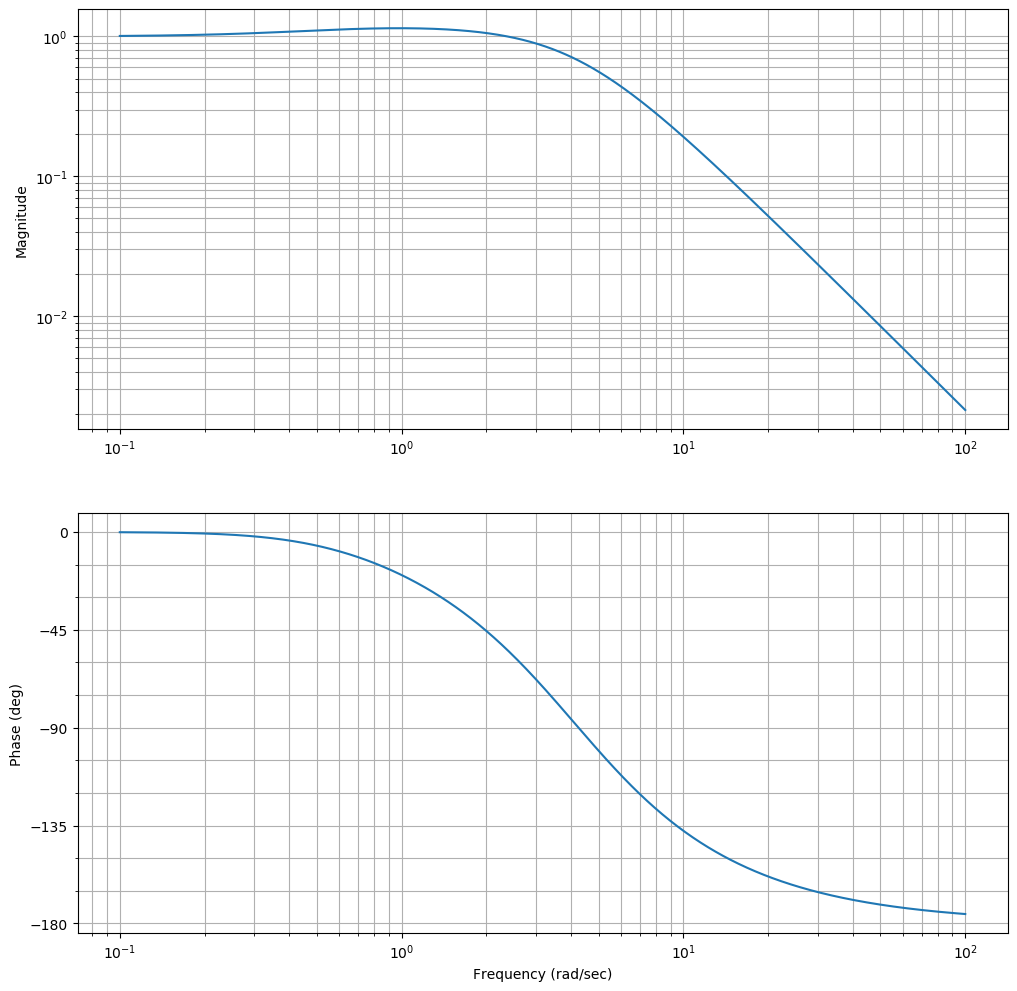

In [2]:
tau = 0.5  # [s] 加速度の追従遅れ
Kp_coef = 0.5  # オーバーシュートを防ぐためIゲインは理論値よりも弱めにする

Ka = 3
Ka_1 = Ka + 1
Kv = Ka_1**2 / 3 / tau
s0 = (-Ka_1 + math.sqrt(Ka_1**2 - 3 * tau * Kv)) / 3 / tau
Kp = -s0 * (tau * s0**2 + Ka_1 * s0 + Kv) * Kp_coef

print(f"s0: {s0}")
print(f"Kp: {Kp}, Kv: {Kv}, Ka: {Ka}")

assert s0 < 0
assert Kp > 0
assert Kv > 0
assert Ka > 0
assert tau * Kp < Kv * Ka_1

num = [Kv, Kp]
den = [tau, Ka_1, Kv, Kp]

plt.figure(figsize=(12, 12))

sys = ctrl.TransferFunction(num, den)
mag, phase, omega = ctrl.bode(sys)

plt.show()